# PokAEmon Interpolator — Training Notebook

Notebook version of model training scripts modified to train on Google Colab. Some exploratory operations also happened in this notebook excliusively, like testing between spherical vs linear interpolation, and creating a distribution dictionary for the latent vectors of all the input images.


In [1]:
import csv
import os
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from PIL import Image
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms

## Configuration

In [2]:
from google.colab import drive
drive.mount('/content/drive')
drive_path = "/content/drive/MyDrive/gen_ai_image_project/"
os.chdir(drive_path)
!ls

Mounted at /content/drive
checkpoints	data	 model_scripts		     pokemon_sprites_old
checkpoints_v2	logs	 model_train.ipynb	     README.md
checkpoint_v2	logs_v2  pokemon_distributions.json  scratch_space
checkpoint_v3	logs_v3  pokemon_sprites


In [ ]:
@dataclass
class VAEConfig:
    # Paths — relative to the project root (where this notebook lives)
    sprites_dir: str = drive_path + "pokemon_sprites"
    checkpoint_dir: str = drive_path + "checkpoint_v3"
    log_dir: str = drive_path + "logs_v3"

    # Image
    image_size: int = 96
    channels: int = 4           # RGBA

    # Model
    latent_dim: int = 128
    hidden_dim: int = 512
    beta: float = 1.0           # KL weight; 1.0 = standard VAE
    encoder_dropout: float = 0.3

    # LR scheduler (ReduceLROnPlateau)
    lr_patience: int = 15
    lr_factor: float = 0.5
    lr_min: float = 1e-6

    # Dataset sampling
    samples_per_pokemon: int = 10                              # augmented views per sprite per epoch
    exclude_sprites: list = None                               # sprite stems to skip (set in __post_init__)
    val_split: float = 0.1                                     # fraction of sprites held out for validation
    split_seed: int = 42                                       # seed for reproducible train/val split

    # Training
    batch_size: int = 64
    epochs: int = 200
    learning_rate: float = 1e-3
    weight_decay: float = 1e-5
    num_workers: int = 4
    pin_memory: bool = True

    # Checkpointing
    save_every: int = 10
    resume_from: str = ""       # set to a .pt path to resume training

    # Logging
    log_interval: int = 50      # print loss every N batches

    def __post_init__(self):
        if self.exclude_sprites is None:
            self.exclude_sprites = ["tyrunt"]

cfg = VAEConfig()


In [4]:

cfg.resume_from = "/content/drive/MyDrive/gen_ai_image_project/checkpoint_v3/vae_epoch_0050.pt"
cfg.epochs = 1000

## Dataset

### Static Loading Dataset (Wrong)

In [5]:
def get_transforms(image_size: int, augment: bool = False) -> transforms.Compose:
    ops = []
    if augment:
        ops.append(transforms.RandomHorizontalFlip())
    ops += [
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),  # scales uint8 → float [0, 1]
    ]
    return transforms.Compose(ops)


class PokemonDataset(Dataset):
    def __init__(self, data_dir: str, image_size: int = 96, augment: bool = False):
        self.paths = sorted(Path(data_dir).glob("*.png"))
        if not self.paths:
            raise FileNotFoundError(f"No PNG files found in {data_dir}")
        self.transform = get_transforms(image_size, augment)

    def __len__(self) -> int:
        return len(self.paths)

    def __getitem__(self, idx: int) -> torch.Tensor:
        img = Image.open(self.paths[idx]).convert("RGBA")
        return self.transform(img)

In [6]:
import argparse
import numpy as np
import os
from pathlib import Path
from PIL import Image, ImageOps
import torch
from torchvision import transforms
from torchvision.transforms import ColorJitter
from torchvision.transforms.functional import rotate
import random


IMAGE_SIZE = 96
NUM_COPIES_PER_IMAGE = 10
TEST_PROPORTION = 0.2
VAL_PROPORTION = 0.1
TRAIN_PROPORTION = 1.0 - TEST_PROPORTION - VAL_PROPORTION

# data augmentation parameters
salt_and_pepper_prob = 0.05
gaussian_noise_std = 0.1
color_jitter_brightness = 0.5
color_jitter_contrast = 0.5
color_jitter_saturation = 0.5
color_jitter_hue = 0.05
rotation_max_angle = 30


def salt_and_pepper(img, p=salt_and_pepper_prob):
    noisy = img.copy()
    rand = np.random.rand(*img.shape)
    noisy[rand < p / 2] = 0.0
    noisy[(rand >= p / 2) & (rand < p)] = 1.0
    return noisy


def gaussian_noise(img, std=gaussian_noise_std):
    noise = np.random.normal(0, std, img.shape)
    noisy = img + noise
    return np.clip(noisy, 0.0, 1.0)


def gaussian_noise_tensor(img, std=gaussian_noise_std):
    noise = torch.randn_like(img) * std
    noisy = img + noise
    return torch.clamp(noisy, 0.0, 1.0)


def apply_random_color_jitter(img, brightness=color_jitter_brightness,
                               contrast=color_jitter_contrast,
                               saturation=color_jitter_saturation,
                               hue=color_jitter_hue):
    jitter = ColorJitter(brightness=brightness, contrast=contrast,
                         saturation=saturation, hue=hue)
    return jitter(img)


def apply_random_rotation(img, max_angle=rotation_max_angle):
    angle = random.uniform(-max_angle, max_angle)
    rotation = rotate(img, angle, fill=255)
    return rotation


# ---------------------------------------------------------------------------
# Core augmentation pipeline
# ---------------------------------------------------------------------------

def augment_image(img: Image.Image) -> Image.Image:
    """Apply random augmentation to a PIL RGBA image, keeping the alpha channel intact."""
    # 1. Random horizontal flip
    if random.random() < 0.5:
        img = ImageOps.mirror(img)

    # 2. Random rotation over the full RGBA tensor; fill=0 keeps background transparent
    tensor = transforms.ToTensor()(img)          # (4, H, W), range [0, 1]
    angle = random.uniform(-rotation_max_angle, rotation_max_angle)
    tensor = rotate(tensor, angle, fill=0.0)
    img = transforms.ToPILImage()(tensor)        # back to RGBA PIL

    # 3. Color jitter on RGB only so alpha is untouched
    r, g, b, a = img.split()
    rgb = Image.merge("RGB", (r, g, b))
    rgb = apply_random_color_jitter(rgb)
    r, g, b = rgb.split()
    img = Image.merge("RGBA", (r, g, b, a))

    # 4. Noise on RGB channels only; alpha stays clean
    arr = np.array(img).astype(np.float32) / 255.0   # (H, W, 4)
    arr[:, :, :3] = gaussian_noise(arr[:, :, :3])
    arr[:, :, :3] = salt_and_pepper(arr[:, :, :3])
    arr = np.clip(arr * 255, 0, 255).astype(np.uint8)
    return Image.fromarray(arr, mode="RGBA")


### Dynamically Sampled Dataset

In [ ]:
import random as _random


def get_train_transforms(image_size: int) -> transforms.Compose:
    return transforms.Compose([
        transforms.Lambda(augment_image),
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
    ])


def get_eval_transforms(image_size: int) -> transforms.Compose:
    return transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
    ])


def split_sprites(sprites_dir, val_split, seed, exclude=None):
    all_paths = sorted(Path(sprites_dir).glob("*.png"))
    exclude_set = set(exclude or [])
    paths = [p for p in all_paths if not any(ex in p.stem for ex in exclude_set)]
    rng = _random.Random(seed)
    shuffled = paths[:]
    rng.shuffle(shuffled)
    n_val = max(1, round(len(shuffled) * val_split))
    return shuffled[n_val:], shuffled[:n_val]  # train, val


class SampledPokemonDataset(Dataset):
    """Draws samples_per_pokemon augmented views of each raw sprite per epoch."""

    def __init__(self, paths: list, image_size: int, samples_per_pokemon: int):
        if not paths:
            raise ValueError("paths list is empty")
        self.paths = paths
        self.samples_per_pokemon = samples_per_pokemon
        self.transform = get_train_transforms(image_size)

    def __len__(self) -> int:
        return len(self.paths) * self.samples_per_pokemon

    def __getitem__(self, idx: int) -> torch.Tensor:
        img = Image.open(self.paths[idx % len(self.paths)]).convert("RGBA")
        return self.transform(img)


class PokemonDataset(Dataset):
    """Loads raw sprites without augmentation (used for validation)."""

    def __init__(self, paths: list, image_size: int = 96):
        if not paths:
            raise ValueError("paths list is empty")
        self.paths = paths
        self.transform = get_eval_transforms(image_size)

    def __len__(self) -> int:
        return len(self.paths)

    def __getitem__(self, idx: int) -> torch.Tensor:
        img = Image.open(self.paths[idx]).convert("RGBA")
        return self.transform(img)


In [ ]:
def build_loaders(cfg):
    train_paths, val_paths = split_sprites(
        cfg.sprites_dir, cfg.val_split, cfg.split_seed, cfg.exclude_sprites
    )
    train_ds = SampledPokemonDataset(train_paths, cfg.image_size, cfg.samples_per_pokemon)
    val_ds = PokemonDataset(val_paths, cfg.image_size)
    train_loader = DataLoader(
        train_ds, batch_size=cfg.batch_size, shuffle=True,
        num_workers=cfg.num_workers, pin_memory=cfg.pin_memory, drop_last=True,
    )
    val_loader = DataLoader(
        val_ds, batch_size=cfg.batch_size, shuffle=False,
        num_workers=cfg.num_workers, pin_memory=cfg.pin_memory,
    )
    return train_loader, val_loader


train_loader, val_loader = build_loaders(cfg)

print(f"Train : {len(train_loader.dataset):>6} images  ({len(train_loader.dataset) // cfg.samples_per_pokemon} sprites × {cfg.samples_per_pokemon} samples)")
print(f"Val   : {len(val_loader.dataset):>6} images")

sample = next(iter(train_loader))
print(f"\nBatch shape  : {sample.shape}")
print(f"dtype / range: {sample.dtype}  [{sample.min():.2f}, {sample.max():.2f}]")


## VAE Architecture

In [9]:
class Encoder(nn.Module):
    def __init__(self, channels: int, hidden_dim: int, latent_dim: int, dropout: float = 0.3):
        super().__init__()
        # 96 → 48 → 24 → 12 → 6
        self.conv = nn.Sequential(
            nn.Conv2d(channels, 32, 4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(32, 64, 4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, 4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128, 256, 4, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
        )
        self.flat_dim = 256 * 6 * 6
        self.fc        = nn.Linear(self.flat_dim, hidden_dim)
        self.dropout   = nn.Dropout(dropout)
        self.fc_mu     = nn.Linear(hidden_dim, latent_dim)
        self.fc_log_var = nn.Linear(hidden_dim, latent_dim)

    def forward(self, x):
        x = self.conv(x).flatten(1)
        x = self.dropout(torch.relu(self.fc(x)))
        return self.fc_mu(x), self.fc_log_var(x)


class Decoder(nn.Module):
    def __init__(self, channels: int, hidden_dim: int, latent_dim: int):
        super().__init__()
        self.flat_dim = 256 * 6 * 6
        self.fc = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_dim, self.flat_dim),
            nn.ReLU(inplace=True),
        )
        # 6 → 12 → 24 → 48 → 96
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(32, channels, 4, stride=2, padding=1),
            nn.Sigmoid(),
        )

    def forward(self, z):
        return self.deconv(self.fc(z).view(-1, 256, 6, 6))


class VAE(nn.Module):
    def __init__(self, channels: int = 4, hidden_dim: int = 512, latent_dim: int = 128,
                 dropout: float = 0.3):
        super().__init__()
        self.encoder = Encoder(channels, hidden_dim, latent_dim, dropout)
        self.decoder = Decoder(channels, hidden_dim, latent_dim)

    def reparameterize(self, mu, log_var):
        return mu + torch.randn_like(mu) * torch.exp(0.5 * log_var)

    def forward(self, x):
        mu, log_var = self.encoder(x)
        return self.decoder(self.reparameterize(mu, log_var)), mu, log_var

    def sample(self, n: int, device: torch.device) -> torch.Tensor:
        z = torch.randn(n, self.encoder.fc_mu.out_features, device=device)
        return self.decoder(z)


def vae_loss(recon, target, mu, log_var, beta=1.0):
    recon_loss = nn.functional.mse_loss(recon, target, reduction="sum") / target.size(0)
    kl_loss    = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp()) / target.size(0)
    return recon_loss + beta * kl_loss, recon_loss, kl_loss

## Training

In [10]:
def save_checkpoint(model, optimizer, scheduler, epoch, loss, path):
    torch.save({
        "epoch": epoch,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "scheduler_state": scheduler.state_dict(),
        "loss": loss,
    }, path)
    print(f"  Checkpoint saved → {path}")


def load_checkpoint(path, model, optimizer, scheduler, device):
    ckpt = torch.load(path, map_location=device)
    model.load_state_dict(ckpt["model_state"])
    optimizer.load_state_dict(ckpt["optimizer_state"])
    if "scheduler_state" in ckpt:
        scheduler.load_state_dict(ckpt["scheduler_state"])
    print(f"Resumed from epoch {ckpt['epoch']}  (loss={ckpt['loss']:.4f})")
    return ckpt["epoch"]

In [11]:
def train_epoch(model, loader, optimizer, device, cfg, epoch):
    model.train()
    total = 0.0
    for i, batch in enumerate(loader):
        batch = batch.to(device)
        optimizer.zero_grad()
        recon, mu, log_var = model(batch)
        loss, recon_l, kl_l = vae_loss(recon, batch, mu, log_var, cfg.beta)
        loss.backward()
        optimizer.step()
        total += loss.item()
        if (i + 1) % cfg.log_interval == 0:
            print(f"  [epoch {epoch}  batch {i+1}/{len(loader)}]"
                  f"  loss={loss.item():.4f}  recon={recon_l.item():.4f}  kl={kl_l.item():.4f}")
    return total / len(loader)


@torch.no_grad()
def eval_epoch(model, loader, device, cfg):
    model.eval()
    total = 0.0
    for batch in loader:
        batch = batch.to(device)
        recon, mu, log_var = model(batch)
        loss, _, _ = vae_loss(recon, batch, mu, log_var, cfg.beta)
        total += loss.item()
    return total / len(loader)

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Path(cfg.checkpoint_dir).mkdir(parents=True, exist_ok=True)
Path(cfg.log_dir).mkdir(parents=True, exist_ok=True)

model = VAE(
    channels=cfg.channels,
    hidden_dim=cfg.hidden_dim,
    latent_dim=cfg.latent_dim,
    dropout=cfg.encoder_dropout,
).to(device)

optimizer = torch.optim.Adam(
    model.parameters(), lr=cfg.learning_rate, weight_decay=cfg.weight_decay
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=cfg.lr_factor,
    patience=cfg.lr_patience, min_lr=cfg.lr_min,
)

start_epoch = 0
if cfg.resume_from:
    print(f"Loading checkpoint from {cfg.resume_from}")
    start_epoch = load_checkpoint(cfg.resume_from, model, optimizer, scheduler, device)

print(f"Parameters : {sum(p.numel() for p in model.parameters()):,}")

Device: cuda
Loading checkpoint from /content/drive/MyDrive/gen_ai_image_project/checkpoint_v3/vae_epoch_0050.pt
Resumed from epoch 50  (loss=1508.2335)
Parameters : 11,026,692


In [ ]:
log_path = os.path.join(cfg.log_dir, "train_log.csv")
with open(log_path, "w") as f:
    f.write("epoch,train_loss,val_loss,lr\n")

val_loss = float("inf")
for epoch in range(start_epoch + 1, cfg.epochs + 1):
    train_loss = train_epoch(model, train_loader, optimizer, device, cfg, epoch)
    val_loss   = eval_epoch(model, val_loader, device, cfg)
    scheduler.step(val_loss)

    current_lr = optimizer.param_groups[0]["lr"]
    print(f"Epoch {epoch}/{cfg.epochs}  train={train_loss:.4f}  val={val_loss:.4f}  lr={current_lr:.2e}")

    with open(log_path, "a") as f:
        f.write(f"{epoch},{train_loss:.6f},{val_loss:.6f},{current_lr:.2e}\n")

    if epoch % cfg.save_every == 0:
        ckpt_path = os.path.join(cfg.checkpoint_dir, f"vae_epoch_{epoch:04d}.pt")
        save_checkpoint(model, optimizer, scheduler, epoch, val_loss, ckpt_path)

final_path = os.path.join(cfg.checkpoint_dir, "vae_final.pt")
save_checkpoint(model, optimizer, scheduler, cfg.epochs, val_loss, final_path)

/tmp/ipykernel_1383/203078658.py:92: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(arr, mode="RGBA")
/tmp/ipykernel_1383/203078658.py:92: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(arr, mode="RGBA")
/tmp/ipykernel_1383/203078658.py:92: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(arr, mode="RGBA")
/tmp/ipykernel_1383/203078658.py:92: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(arr, mode="RGBA")


  [epoch 51  batch 50/160]  loss=1638.0040  recon=1588.6761  kl=49.3279
  [epoch 51  batch 100/160]  loss=1532.2545  recon=1481.5471  kl=50.7074
  [epoch 51  batch 150/160]  loss=1432.1488  recon=1384.6921  kl=47.4567
Epoch 51/1000  train=1569.7892  val=1492.8268  lr=1.00e-03


/tmp/ipykernel_1383/203078658.py:92: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(arr, mode="RGBA")
/tmp/ipykernel_1383/203078658.py:92: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(arr, mode="RGBA")
/tmp/ipykernel_1383/203078658.py:92: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(arr, mode="RGBA")
/tmp/ipykernel_1383/203078658.py:92: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(arr, mode="RGBA")


  [epoch 52  batch 50/160]  loss=1562.5255  recon=1513.3704  kl=49.1552
  [epoch 52  batch 100/160]  loss=1649.5229  recon=1598.5367  kl=50.9862
  [epoch 52  batch 150/160]  loss=1605.3666  recon=1553.8843  kl=51.4823
Epoch 52/1000  train=1563.4641  val=1486.5396  lr=1.00e-03


/tmp/ipykernel_1383/203078658.py:92: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(arr, mode="RGBA")
/tmp/ipykernel_1383/203078658.py:92: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(arr, mode="RGBA")
/tmp/ipykernel_1383/203078658.py:92: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(arr, mode="RGBA")
/tmp/ipykernel_1383/203078658.py:92: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(arr, mode="RGBA")


...

  [epoch 423  batch 50/160]  loss=1252.4309  recon=1195.4597  kl=56.9712
  [epoch 423  batch 100/160]  loss=1208.5527  recon=1150.5712  kl=57.9816
  [epoch 423  batch 150/160]  loss=1254.7631  recon=1197.5649  kl=57.1982
Epoch 423/1000  train=1234.9459  val=1184.0522  lr=1.00e-03


/tmp/ipykernel_1383/203078658.py:92: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(arr, mode="RGBA")
/tmp/ipykernel_1383/203078658.py:92: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(arr, mode="RGBA")
/tmp/ipykernel_1383/203078658.py:92: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(arr, mode="RGBA")
/tmp/ipykernel_1383/203078658.py:92: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(arr, mode="RGBA")


  [epoch 424  batch 50/160]  loss=1267.2064  recon=1210.6621  kl=56.5443
  [epoch 424  batch 100/160]  loss=1228.5481  recon=1171.7561  kl=56.7919
  [epoch 424  batch 150/160]  loss=1263.8439  recon=1207.2910  kl=56.5528
Epoch 424/1000  train=1232.3568  val=1178.5369  lr=1.00e-03


/tmp/ipykernel_1383/203078658.py:92: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(arr, mode="RGBA")
/tmp/ipykernel_1383/203078658.py:92: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(arr, mode="RGBA")
/tmp/ipykernel_1383/203078658.py:92: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(arr, mode="RGBA")
/tmp/ipykernel_1383/203078658.py:92: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(arr, mode="RGBA")


  [epoch 425  batch 50/160]  loss=1289.4464  recon=1231.9757  kl=57.4708
  [epoch 425  batch 100/160]  loss=1233.2330  recon=1178.2205  kl=55.0125


## Visualize Reconstructions

Run after training (or after loading a checkpoint) to compare originals with their VAE reconstructions.

In [ ]:
@torch.no_grad()
def show_reconstructions(model, loader, device, n=8):
    model.eval()
    batch = next(iter(loader))[:n].to(device)
    recon, _, _ = model(batch)

    fig, axes = plt.subplots(2, n, figsize=(n * 1.6, 3.5))
    for i in range(n):
        orig = batch[i].cpu().permute(1, 2, 0).numpy()
        rec  = recon[i].cpu().permute(1, 2, 0).numpy()
        axes[0, i].imshow(orig[:, :, :3])
        axes[0, i].axis("off")
        axes[1, i].imshow(rec[:, :, :3])
        axes[1, i].axis("off")

    axes[0, 0].set_title("Original",      fontsize=9, loc="left")
    axes[1, 0].set_title("Reconstructed", fontsize=9, loc="left")
    plt.tight_layout()
    plt.show()

show_reconstructions(model, val_loader, device)


In [ ]:
def get_latent_vector(model, image_path, device):
    model.eval()
    transform = get_eval_transforms(cfg.image_size)
    img = Image.open(image_path).convert("RGBA")
    img_tensor = transform(img).unsqueeze(0).to(device)
    with torch.no_grad():
        mu, log_var = model.encoder(img_tensor)
    return mu, log_var


## Create the Distribution Reference for every Pokemon

This reference is used by the Azure container app service to interpolate every image. The encoder is not used in the API. Instead the distributions of each image are stored, sampled, interpolated, and then passed through the decoder to get the resulting image

In [ ]:
import json

directory = "/content/drive/MyDrive/gen_ai_image_project/pokemon_sprites/"
lat_dist_dict = {}
for i in range(1, 1026):
    match = next((f for f in os.listdir(directory) if f.startswith(f"{i}_")), None)
    if i == 696:
      print("skip tyrunt sdge :(")
      continue
    if match:
        filepath = os.path.join(directory, match)
        mu, logvar = get_latent_vector(model, filepath, device)
        lat_dist_dict[i] = {'mean': mu.cpu().numpy().tolist()[0], 'log_var':logvar.cpu().numpy().tolist()[0]}
        print("Saved distrbution for " + match)
with open("/content/drive/MyDrive/gen_ai_image_project/pokemon_distributions.json", 'w') as f:
  json.dump(lat_dist_dict, f)



Saved distrbution for 1_bulbasaur.png
Saved distrbution for 2_ivysaur.png
Saved distrbution for 3_venusaur.png
Saved distrbution for 4_charmander.png
Saved distrbution for 5_charmeleon.png
Saved distrbution for 6_charizard.png
Saved distrbution for 7_squirtle.png
Saved distrbution for 8_wartortle.png
Saved distrbution for 9_blastoise.png
Saved distrbution for 10_caterpie.png
Saved distrbution for 11_metapod.png
Saved distrbution for 12_butterfree.png
Saved distrbution for 13_weedle.png
Saved distrbution for 14_kakuna.png
Saved distrbution for 15_beedrill.png
Saved distrbution for 16_pidgey.png
Saved distrbution for 17_pidgeotto.png
Saved distrbution for 18_pidgeot.png
Saved distrbution for 19_rattata.png
Saved distrbution for 20_raticate.png
Saved distrbution for 21_spearow.png
Saved distrbution for 22_fearow.png
Saved distrbution for 23_ekans.png
Saved distrbution for 24_arbok.png
Saved distrbution for 25_pikachu.png
Saved distrbution for 26_raichu.png
Saved distrbution for 27_sandshr

## Loss Curve

In [ ]:
epochs_log, train_losses, val_losses, lrs = [], [], [], []
with open(log_path) as f:
    for row in csv.DictReader(f):
        epochs_log.append(int(row["epoch"]))
        train_losses.append(float(row["train_loss"]))
        val_losses.append(float(row["val_loss"]))
        lrs.append(float(row["lr"]))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs_log, train_losses, label="Train")
ax1.plot(epochs_log, val_losses,   label="Validation")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("VAE Training Loss")
ax1.legend()

ax2.plot(epochs_log, lrs, color="orange")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Learning Rate")
ax2.set_title("Learning Rate Schedule")
ax2.set_yscale("log")

plt.tight_layout()
plt.show()

## Comparing Spherical and Linear Interpolation

In [ ]:
import torch
import math
import matplotlib.pyplot as plt
import numpy as np

# Function 1: Spherical Linear Interpolation
def slerp_latent_vector(index1, index2, alpha, device, lat_dist_dict):
    """
    Performs spherical linear interpolation (slerp) between the mean latent vectors
    of two images identified by their indices.

    Args:
        index1 (int): Index of the first image.
        index2 (int): Index of the second image.
        alpha (float): Interpolation factor between 0.0 and 1.0.
                       0.0 returns latent vector of index1, 1.0 returns latent vector of index2.
        device (torch.device): The device (cuda or cpu) for tensors.
        lat_dist_dict (dict): Dictionary containing 'mean' and 'log_var' for each image index.

    Returns:
        torch.Tensor: The interpolated latent vector.
    """
    if index1 not in lat_dist_dict or index2 not in lat_dist_dict:
        raise ValueError("One or both image indices not found in lat_dist_dict.")

    # Get mean latent vectors (mu) for both images
    mu1 = torch.tensor(lat_dist_dict[index1]['mean'], dtype=torch.float32).to(device)
    mu2 = torch.tensor(lat_dist_dict[index2]['mean'], dtype=torch.float32).to(device)

    # Handle alpha edge cases directly
    if alpha <= 0:
        return mu1
    if alpha >= 1:
        return mu2

    # Normalize vectors
    v0 = mu1 / torch.norm(mu1)
    v1 = mu2 / torch.norm(mu2)

    # Compute angle between vectors
    dot_product = torch.dot(v0, v1).clamp(-1.0, 1.0) # Clamp to avoid numerical instability
    theta = math.acos(dot_product.item())

    # If angle is very small, vectors are nearly collinear, use linear interpolation
    if theta < 1e-6:
        return (1 - alpha) * mu1 + alpha * mu2

    # Perform slerp
    slerp_vector = (math.sin((1 - alpha) * theta) / math.sin(theta)) * mu1 + \
                   (math.sin(alpha * theta) / math.sin(theta)) * mu2

    return slerp_vector

# Function 2: Decode and Visualize
@torch.no_grad()
def decode_and_visualize(latent_vector, model, device):
    """
    Decodes a latent vector using the VAE decoder and visualizes the resulting image.

    Args:
        latent_vector (torch.Tensor): The latent vector to decode.
        model (nn.Module): The VAE model.
        device (torch.device): The device (cuda or cpu) for tensors.
    """
    model.eval() # Set model to evaluation mode

    # Ensure latent_vector is on the correct device and has a batch dimension
    latent_vector = latent_vector.to(device).unsqueeze(0)

    # Decode the latent vector
    decoded_image = model.decoder(latent_vector)

    # Convert to numpy and prepare for plotting
    img = decoded_image.squeeze(0).cpu().permute(1, 2, 0).numpy()

    # Plot the image
    plt.figure(figsize=(4,4)) # Create a figure for the image
    plt.imshow(img[:, :, :3]) # Assuming RGBA, plot RGB channels
    plt.axis('off')
    plt.title("Decoded Image")
    plt.show()

In [ ]:
# Function 3: Linear Interpolation
def linear_interpolate_latent_vector(index1, index2, alpha, device, lat_dist_dict):
    """
    Performs linear interpolation between the mean latent vectors
    of two images identified by their indices.

    Args:
        index1 (int): Index of the first image.
        index2 (int): Index of the second image.
        alpha (float): Interpolation factor between 0.0 and 1.0.
                       0.0 returns latent vector of index1, 1.0 returns latent vector of index2.
        device (torch.device): The device (cuda or cpu) for tensors.
        lat_dist_dict (dict): Dictionary containing 'mean' and 'log_var' for each image index.

    Returns:
        torch.Tensor: The interpolated latent vector.
    """
    if index1 not in lat_dist_dict or index2 not in lat_dist_dict:
        raise ValueError("One or both image indices not found in lat_dist_dict.")

    # Get mean latent vectors (mu) for both images
    mu1 = torch.tensor(lat_dist_dict[index1]['mean'], dtype=torch.float32).to(device)
    mu2 = torch.tensor(lat_dist_dict[index2]['mean'], dtype=torch.float32).to(device)

    # Perform linear interpolation
    interpolated_vector = (1 - alpha) * mu1 + alpha * mu2

    return interpolated_vector

In [ ]:
poke_1 = 600
poke_2 = 30
alpha = .5

In [ ]:
latent_vector_slerp = slerp_latent_vector(poke_1, poke_2, alpha, device, lat_dist_dict)
latent_vector = linear_interpolate_latent_vector(poke_1, poke_2, alpha, device, lat_dist_dict)

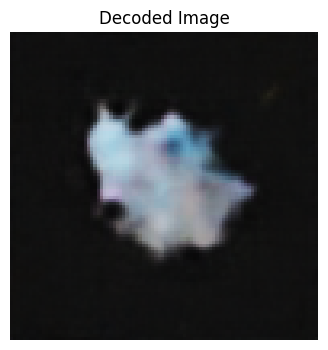

In [ ]:
decode_and_visualize(latent_vector_slerp, model, device)

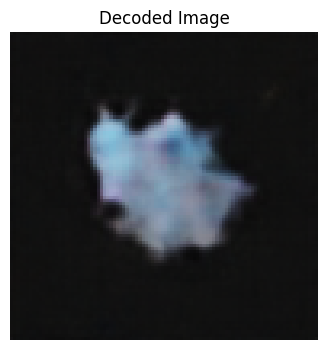

In [ ]:
decode_and_visualize(latent_vector, model, device)